Created by: Xiaoling Sundberg

Created on: March 27, 2026

Last edited: April 01, 2026

In [44]:
# import libraries 
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

import os
os.chdir("../Data")

In [45]:
# read in stata data using pd.read_stata() 
df = pd.read_stata("megamillions_tickets_fl.dta")

<br>

# Data Exploration

### Data pre-view

In [46]:
# check the shape
print(df.shape)

(610, 27)


In [47]:
# print the first 5 rows
print(df.head())

   draw_date  winners  jackpot  covid  covid_cases  tuesday  unempr_a  unempr  \
0 2016-05-03    46430      128      0            0        1       4.9     4.6   
1 2016-05-06    51557      138      0            0        0       4.9     4.6   
2 2016-05-10    52520      150      0            0        1       4.9     4.6   
3 2016-05-13    55865      161      0            0        0       4.9     4.6   
4 2016-05-17    52194      174      0            0        1       4.9     4.6   

   jan  feb  ...  oct  nov  dec  year2016  year2017  year2018  year2019  \
0    0    0  ...    0    0    0         1         0         0         0   
1    0    0  ...    0    0    0         1         0         0         0   
2    0    0  ...    0    0    0         1         0         0         0   
3    0    0  ...    0    0    0         1         0         0         0   
4    0    0  ...    0    0    0         1         0         0         0   

   year2020  year2021  year2022  
0         0         0       

In [48]:
# print the last 5 rows
print(df.tail())

     draw_date  winners  jackpot  covid  covid_cases  tuesday  unempr_a  \
605 2022-02-18    17773       64      1         5423        0       3.3   
606 2022-02-22    20469       75      1         3892        1       3.3   
607 2022-02-25    19804       87      1         2713        0       3.3   
608 2022-03-01    19927      102      1         1747        1       3.2   
609 2022-03-04    20408      113      1         1739        0       3.2   

     unempr  jan  feb  ...  oct  nov  dec  year2016  year2017  year2018  \
605     3.1    0    1  ...    0    0    0         0         0         0   
606     3.1    0    1  ...    0    0    0         0         0         0   
607     3.1    0    1  ...    0    0    0         0         0         0   
608     2.7    0    0  ...    0    0    0         0         0         0   
609     2.7    0    0  ...    0    0    0         0         0         0   

     year2019  year2020  year2021  year2022  
605         0         0         0         1  
606   

In [49]:
# check column names
df.columns

Index(['draw_date', 'winners', 'jackpot', 'covid', 'covid_cases', 'tuesday',
       'unempr_a', 'unempr', 'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul',
       'aug', 'sept', 'oct', 'nov', 'dec', 'year2016', 'year2017', 'year2018',
       'year2019', 'year2020', 'year2021', 'year2022'],
      dtype='object')

# Target variable: tickets_sold

In [50]:
# create target variable tickets_sold
df["tickets_sold"] = df["winners"] * 36.63

In [51]:
# change variable names
df = df.rename(columns={
    "draw_date": "draw_date",
    "winners": "winners",
    "jackpot": "jackpot_amount($)",
    "unempr": "unemployment_rate",
    "unempr_a": "unemployment_rate_adjusted"
})


In [52]:
# check column names
df.columns

Index(['draw_date', 'winners', 'jackpot_amount($)', 'covid', 'covid_cases',
       'tuesday', 'unemployment_rate_adjusted', 'unemployment_rate', 'jan',
       'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sept', 'oct', 'nov',
       'dec', 'year2016', 'year2017', 'year2018', 'year2019', 'year2020',
       'year2021', 'year2022', 'tickets_sold'],
      dtype='object')

### Summary Statistics

In [53]:
# Define Pre-covid and Covid periods: cut off date: March 03, 2020 (first covid case recorded in the United States)
df["covid_period"] = np.where(
    df["draw_date"] >= pd.Timestamp("2020-03-04"),
    1,
    0
)

In [54]:
# summary statistics
print(df.describe())

                 draw_date        winners  jackpot_amount($)       covid  \
count                  610     610.000000         610.000000  610.000000   
mean   2019-04-03 12:00:00   33901.777049         153.226230    0.344262   
min    2016-05-03 00:00:00   10565.000000          15.000000    0.000000   
25%    2017-10-17 18:00:00   17162.000000          51.250000    0.000000   
50%    2019-04-03 12:00:00   23927.500000         106.000000    0.000000   
75%    2020-09-17 06:00:00   35422.000000         210.250000    1.000000   
max    2022-03-04 00:00:00  680576.000000        1600.000000    1.000000   
std                    NaN   44898.304751         148.222954    0.475517   

        covid_cases    tuesday  unemployment_rate_adjusted  unemployment_rate  \
count    610.000000  610.00000                  610.000000         610.000000   
mean    2854.563934    0.50000                    4.769836           4.766393   
min        0.000000    0.00000                    2.700000           2.5

In [55]:
# summary statistics before and after covid
print("MegaMillions Tickets Sold Before Covid:")
print(df.loc[df["covid"] == 0, ["tickets_sold"]].describe())

print("MegaMillions Tickets Sold During Covid:")
print(df.loc[df["covid"] == 1, ["tickets_sold"]].describe())

MegaMillions Tickets Sold Before Covid:
       tickets_sold
count  4.000000e+02
mean   1.396411e+06
std    1.862690e+06
min    3.869960e+05
25%    6.901733e+05
50%    1.032893e+06
75%    1.451510e+06
max    2.492950e+07
MegaMillions Tickets Sold During Covid:
       tickets_sold
count  2.100000e+02
mean   9.473666e+05
std    1.060548e+06
min    4.079483e+05
25%    5.714188e+05
50%    6.839920e+05
75%    9.236529e+05
max    1.064677e+07


Florida MegaMillions ticket sales were lower during the Covid period. The mean declined from about 1.40 million tickets before Covid to about 0.95 million during Covid, and the median declined from about 1.03 million to about 0.68 million. The standard deviation also decreased from about 1.86 million to about 1.06 million, and the maximum fell from about 24.93 million to about 10.65 million. This suggests that ticket sales were lower and less variable during Covid, with fewer extreme high-sales observations.

### Visualization/Graphs

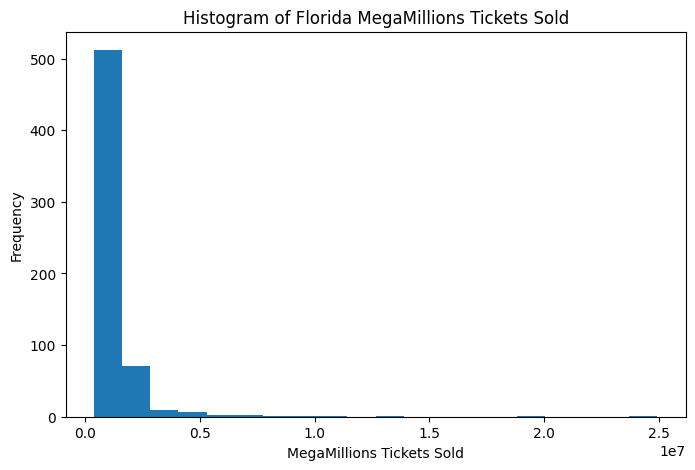

In [56]:
# histogram - show tickets sold distribution 
plt.figure(figsize=(8,5))
plt.hist(df["tickets_sold"],bins=20)
plt.xlabel("MegaMillions Tickets Sold")
plt.ylabel("Frequency")
plt.title("Histogram of Florida MegaMillions Tickets Sold")
plt.show()

Florida MegaMillions ticket sales are heavily right-skewed. Most observations are concentrated below about 3 million tickets, while the distribution has a long right tail with extreme high-sales observations reaching about 25 million tickets. This indicates substantial skewness and high-value outliers, suggesting that a log transformation may be appropriate before modeling.

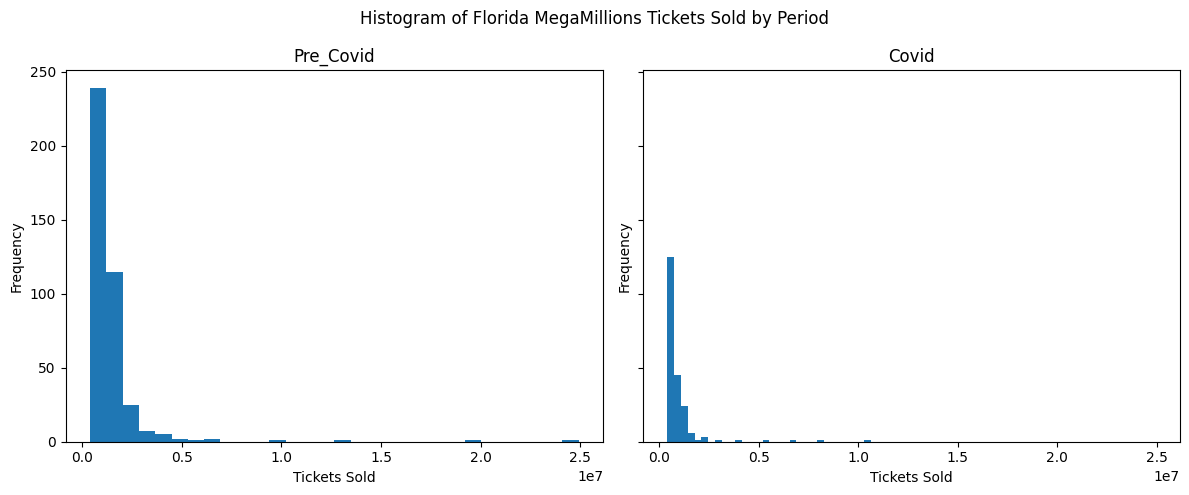

In [57]:
# histogram of tickets sold by periods for comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Pre-Covid
axes[0].hist(df.loc[df["covid"] == 0, "tickets_sold"], bins=30)
axes[0].set_title("Pre_Covid")
axes[0].set_xlabel("Tickets Sold")
axes[0].set_ylabel("Frequency")

# Covid
axes[1].hist(df.loc[df["covid"] == 1, "tickets_sold"], bins=30)
axes[1].set_title("Covid")
axes[1].set_xlabel("Tickets Sold")
axes[1].set_ylabel("Frequency")

plt.suptitle("Histogram of Florida MegaMillions Tickets Sold by Period")
plt.tight_layout()
plt.show()

Florida MegaMillions ticket sales are right-skewed in both the Pre_Covid and Covid periods. The Pre_Covid distribution has a wider spread and more extreme high-sales observations, while the Covid distribution is more concentrated at lower ticket-sales values. This suggests that ticket sales were generally lower and less variable during Covid, with fewer unusually large sales outcomes.

<br>

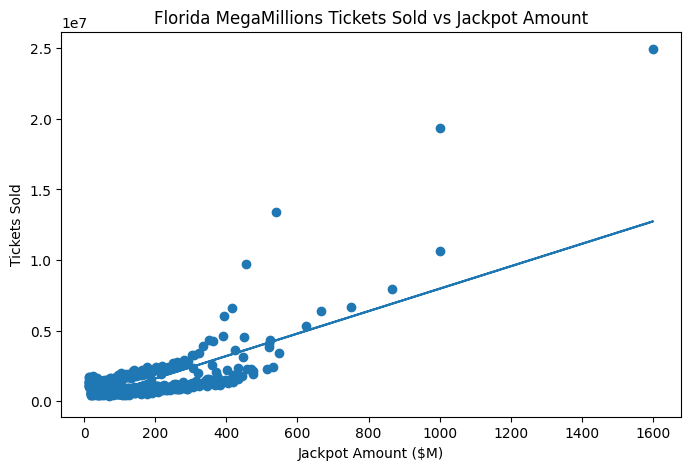

In [58]:
# scatter plot - show how tickets sold changes as the amount of jackpot changes

plt.figure(figsize=(8,5))
plt.scatter(df["jackpot_amount($)"],df["tickets_sold"])

m,b = np.polyfit(df["jackpot_amount($)"], df["tickets_sold"],1)
plt.plot(df["jackpot_amount($)"], m*df["jackpot_amount($)"]+b)

plt.xlabel("Jackpot Amount ($M)")
plt.ylabel("Tickets Sold")
plt.title("Florida MegaMillions Tickets Sold vs Jackpot Amount")
plt.show()

Florida MegaMillions ticket sales show a positive association with jackpot amount. As the jackpot increases, ticket sales generally increase as well, although the spread becomes much wider at higher jackpot levels. This suggests that larger jackpots are associated with higher ticket sales, but also with greater variability and several extreme high-sales observations.

<br>

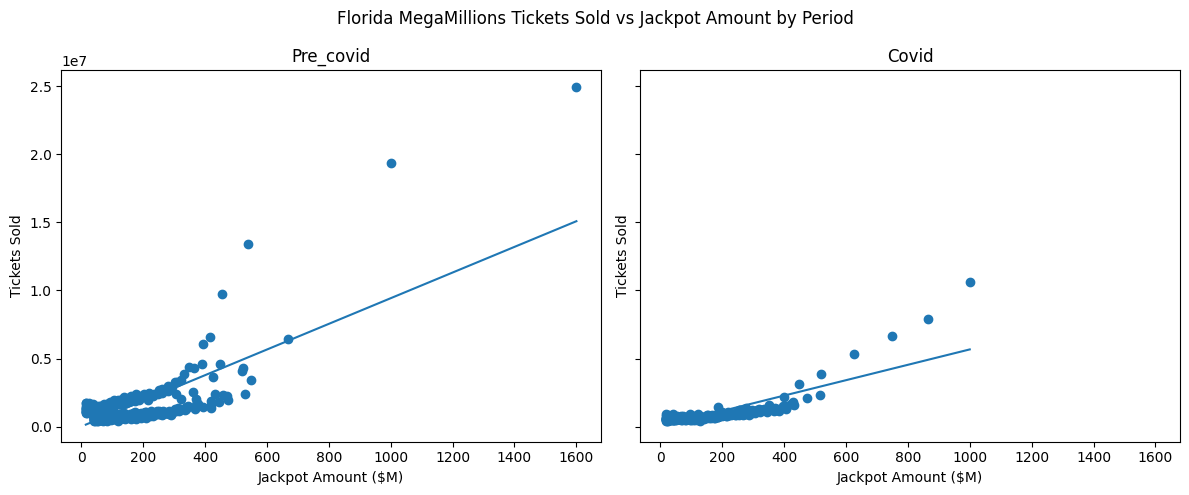

In [59]:
# set the same scale for both scatter plots and regression lines 
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Pre-Covid
x_pre = df.loc[df["covid"] == 0, "jackpot_amount($)"] # locate the covid==0 rows, and take the corresponding jackpot 
y_pre = df.loc[df["covid"] == 0, "tickets_sold"] # locate the covid==0 rows, and take the corresponding tickets sold 

axes[0].scatter(x_pre, y_pre)
slope_pre, intercept_pre = np.polyfit(x_pre, y_pre, 1)
x_pre_sorted = np.sort(x_pre)
axes[0].plot(x_pre_sorted, slope_pre * x_pre_sorted + intercept_pre)
axes[0].set_title("Pre_covid")
axes[0].set_xlabel("Jackpot Amount ($M)")
axes[0].set_ylabel("Tickets Sold")

# Covid
x_covid = df.loc[df["covid"] == 1, "jackpot_amount($)"]
y_covid = df.loc[df["covid"] == 1, "tickets_sold"]

axes[1].scatter(x_covid, y_covid)
slope_covid, intercept_covid = np.polyfit(x_covid, y_covid, 1)
x_covid_sorted = np.sort(x_covid)
axes[1].plot(x_covid_sorted, slope_covid * x_covid_sorted + intercept_covid)
axes[1].set_title("Covid")
axes[1].set_xlabel("Jackpot Amount ($M)")
axes[1].set_ylabel("Tickets Sold")

plt.suptitle("Florida MegaMillions Tickets Sold vs Jackpot Amount by Period")
plt.tight_layout() # adjust spacing automatically (e.g., prevents title overlapping..)
plt.show()

In both the Pre_Covid and Covid periods, Florida MegaMillions ticket sales increase as jackpot amount increases. However, the relationship appears stronger in the Pre_Covid period, where the fitted line is steeper and the highest ticket-sales observations are larger. During Covid, ticket sales still rise with jackpot size, but the response appears weaker and the overall level of ticket sales is lower for comparable jackpot amounts.

<br>

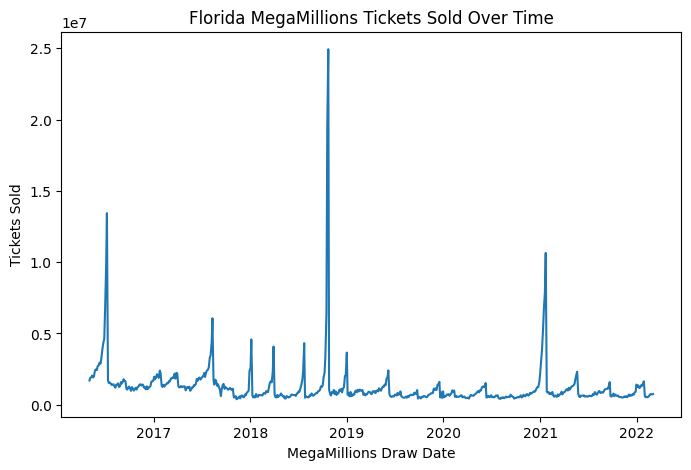

In [60]:
# line plot - show how tickets sold change over time 
plt.figure(figsize=(8,5))
plt.plot(df["draw_date"],df["tickets_sold"])
plt.xlabel("MegaMillions Draw Date")
plt.ylabel("Tickets Sold")
plt.title("Florida MegaMillions Tickets Sold Over Time")
plt.show()

Florida MegaMillions ticket sales fluctuate substantially over time, with several sharp spikes corresponding to unusually high-sales draws. Ticket sales appear somewhat lower and less volatile during much of the Covid period, especially around 2020, before rising again later. The series also contains several extreme spikes, including one in late 2018 exceeding 25 million tickets sold.

<br>

<Figure size 800x500 with 0 Axes>

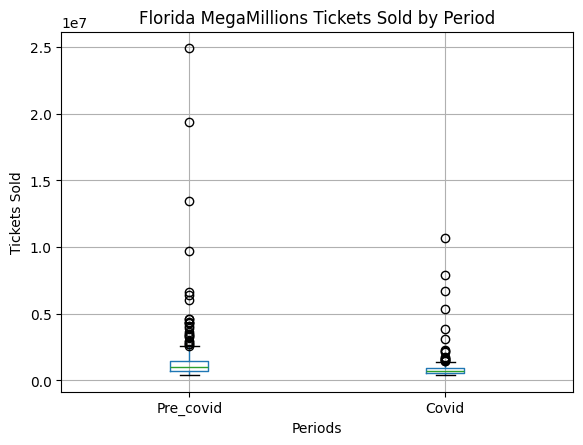

In [61]:
# boxplot 
# define a new variable "covid_label" - using map() -  covid_period =0 as "Pre_covid" and =1 as "Covid"
# pre_covid: May 04,2016 - March 03,2020; covid: March 04,2020 - March 07, 2022 
# May 04, 2016 is the earliest date lottery information could be found online and March 07 is the day this project began.
df["covid_label"] = pd.Categorical(
    df["covid_period"].map({0:"Pre_covid", 1:"Covid"}),
    categories=["Pre_covid", "Covid"],
    ordered=True
) # used pd.Categorical() to treat "covid_label" as categorical and not ordinal; ordered=True ensures Pre_covid is in front of Covid

plt.figure(figsize=(8,5))
df.boxplot(column = "tickets_sold", by="covid_label")

plt.title("Florida MegaMillions Tickets Sold by Period")
plt.suptitle("") # to clean the auto title 
plt.xlabel("Periods")
plt.ylabel("Tickets Sold")
plt.show()

The boxplot shows that Florida MegaMillions ticket sales had a higher median and wider spread in the Pre_Covid period than during Covid. Both periods contain many high-sales outliers, but the most extreme observations occurred before Covid, including one above 25 million tickets sold. This suggests that ticket sales were generally lower and less variable during Covid, with fewer extremely large sales draws.

<br>

In [62]:
# correlation coefficient tests on tickets sold and jackpot amount 
# Pearson's p and Spearman Rank Order Correlation 
print("Pearson's Correlation:")
print(df[["jackpot_amount($)","tickets_sold"]].corr(method="pearson"))

print("Spearman's Correlation:")
print(df[["jackpot_amount($)","tickets_sold"]].corr(method="spearman"))

Pearson's Correlation:
                   jackpot_amount($)  tickets_sold
jackpot_amount($)           1.000000      0.716351
tickets_sold                0.716351      1.000000
Spearman's Correlation:
                   jackpot_amount($)  tickets_sold
jackpot_amount($)            1.00000       0.44485
tickets_sold                 0.44485       1.00000


Florida MegaMillions ticket sales and jackpot amount are positively associated. The Pearson correlation (0.716) indicates a fairly strong positive linear relationship, while the Spearman correlation (0.445) indicates a moderate positive monotonic relationship. Together, these suggest that ticket sales generally increase as the jackpot increases, although the relationship is influenced by skewness and a few extreme observations.

<br>

All graphs and summary statistics indicate that the data is heavily right-skewed and contains several extremely high-value tickets sold outliers. To ensure a robust model, I will analyze these outliers before building the models.

# Outlier Detection for tickets solds
### 3 standard deviation rule 
### Hampel Identifier
### IQR - already done above

In [63]:
# 3 standard deviation rule 
mean_tickets_sold = df["tickets_sold"].mean()
std_tickets_sold = df["tickets_sold"].std()

lower_3std = mean_tickets_sold - 3*std_tickets_sold
upper_3std = mean_tickets_sold + 3*std_tickets_sold

outliers_std = df[(df["tickets_sold"]<lower_3std)|(df["tickets_sold"]>upper_3std)]

print("3 Standard Deviation Rule:")
print("Lower Bound:", lower_3std)
print("Upper Bound:", upper_3std)
print("Number of Outliers", outliers_std.shape[0])

print(outliers_std[["draw_date","jackpot_amount($)","tickets_sold"]])

3 Standard Deviation Rule:
Lower Bound: -3692052.6157957166
Upper Bound: 6175696.802418668
Number of Outliers 9
     draw_date  jackpot_amount($)  tickets_sold
17  2016-07-01                415    6608894.49
18  2016-07-05                454    9719880.39
19  2016-07-08                540   13434675.21
256 2018-10-16                667    6420359.88
257 2018-10-19               1000   19365255.36
258 2018-10-23               1600   24929498.88
491 2021-01-15                750    6677282.70
492 2021-01-19                865    7921054.35
493 2021-01-22               1000   10646765.91


9 rows of outliers are detected. Since the outlier proportion is about 1.5% (slightly above the 1% 3std rule threshold), a Hampel comparison is considered.

In [64]:
# hampel identifier 
    ## the hampel use median and MAD is the core part
# MAD:
    ## first calculate the absolute deviation: abs(tickets_sold - median_tickets_sold)
    ## then take the median of those absolute deviations

# Hampel score:
    ## absolute deviation divided by (1.4826 * MAD)
median_tickets_sold = df["tickets_sold"].median()

MAD = np.median(np.abs(df["tickets_sold"]-median_tickets_sold))

hampel_score = np.abs(df["tickets_sold"]-median_tickets_sold)/(1.4826*MAD)

outliers_hampel = df[hampel_score>3]

print("Hample Outliers:")
print("Median:", median_tickets_sold)
print("MAD:", MAD)
print("Number of Outliers:", outliers_hampel.shape[0])

print(outliers_hampel[["draw_date","jackpot_amount($)","tickets_sold"]])

Hample Outliers:
Median: 876464.3250000001
MAD: 303186.51000000007
Number of Outliers: 46
     draw_date  jackpot_amount($)  tickets_sold
6   2016-05-24                203    2417360.22
7   2016-05-27                218    2475968.22
8   2016-05-31                235    2431316.25
9   2016-06-03                251    2713147.47
10  2016-06-07                260    2748825.09
11  2016-06-10                280    2955381.66
12  2016-06-14                293    2875198.59
13  2016-06-17                310    3266480.25
14  2016-06-21                333    3899226.87
15  2016-06-24                363    4288310.73
16  2016-06-28                390    4633475.22
17  2016-07-01                415    6608894.49
18  2016-07-05                454    9719880.39
19  2016-07-08                540   13434675.21
76  2017-01-24                177    2393733.87
94  2017-03-28                162    2237250.51
124 2017-07-11                202    2231462.97
126 2017-07-18                232    2267690.0

Hampel detected 46 outlier rows, which is substantially higher than the 3 standard deviation rule. Given the right-skewed distribution of the data, this suggests that the 3 standard deviation rule may be influenced by extreme values because it depends on the mean and standard deviation. The IQR method will be considered next.

In [65]:
# IQR
Q1 = df["tickets_sold"].quantile(0.25)
Q3 = df["tickets_sold"].quantile(0.75)
IQR = Q3-Q1

lower_IQR = Q1 - 1.5*IQR
upper_IQR = Q3 + 1.5*IQR

outliers_IQR = df[(df["tickets_sold"]<lower_IQR)|(df["tickets_sold"]>upper_IQR)]

print("Interquartile Range (IQR) Outliers:")
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_IQR)
print("Upper Bound:", upper_IQR)
print("Number of Outliers:", outliers_IQR.shape[0])

print(outliers_IQR[["draw_date","jackpot_amount($)","tickets_sold"]])

Interquartile Range (IQR) Outliers:
Q1: 628644.06
Q3: 1297507.86
IQR: 668863.8
Lower Bound: -374651.64
Upper Bound: 2300803.56
Number of Outliers: 42
     draw_date  jackpot_amount($)  tickets_sold
6   2016-05-24                203    2417360.22
7   2016-05-27                218    2475968.22
8   2016-05-31                235    2431316.25
9   2016-06-03                251    2713147.47
10  2016-06-07                260    2748825.09
11  2016-06-10                280    2955381.66
12  2016-06-14                293    2875198.59
13  2016-06-17                310    3266480.25
14  2016-06-21                333    3899226.87
15  2016-06-24                363    4288310.73
16  2016-06-28                390    4633475.22
17  2016-07-01                415    6608894.49
18  2016-07-05                454    9719880.39
19  2016-07-08                540   13434675.21
76  2017-01-24                177    2393733.87
127 2017-07-21                248    2400583.68
128 2017-07-25                262 

IQR detected 42 outliers, which is very similar to the Hampel identifier (46). This suggests that for this right skewed variable, the 3 std method is influenced by large outliers. Therefore the more robust methods IQR and Hampel appear to be more appropriate for detecting outliers. 
This means that the data are not well behaved enough to rely on the mean-based rule; therefore, when modeling, a more robust approach is preferred such as using "log tickets sold" instead of the raw dollar valued "log tickets sold as the target variable.

<br>

# Create a Log Transformed Target Variable:
### log_tickets_sold

In [66]:
# use log transformation to reduce the skewness of the data
df["log_tickets_sold"] = np.log(df["tickets_sold"])

In [67]:
print(df["log_tickets_sold"].describe())

count    610.000000
mean      13.787039
std        0.582044
min       12.866170
25%       13.351317
50%       13.683650
75%       14.075955
max       17.031562
Name: log_tickets_sold, dtype: float64


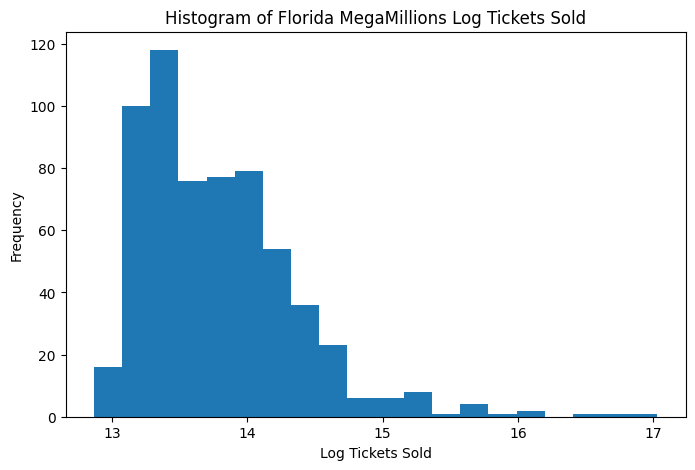

In [68]:
# log_tickets_sold histogram 
plt.figure(figsize=(8,5))
plt.hist(df["log_tickets_sold"],bins=20)
plt.xlabel("Log Tickets Sold")
plt.ylabel("Frequency")
plt.title("Histogram of Florida MegaMillions Log Tickets Sold")
plt.show()

After the log transformation, the distribution of Florida MegaMillions tickets sold becomes more symmetric and closer to a normal distribution, although some right skew remains.

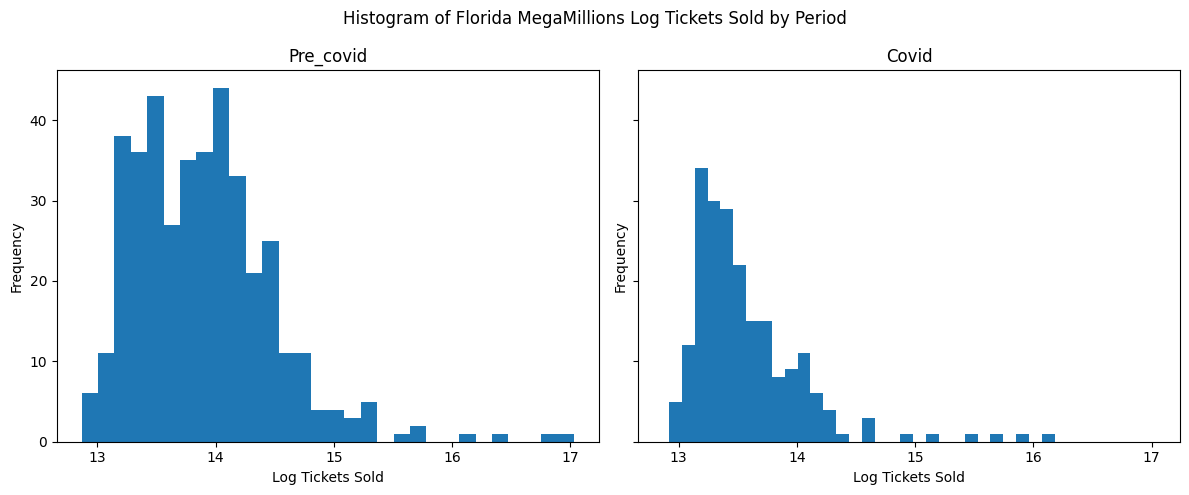

In [69]:
# histogram of log tickets sold by periods for comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Pre-Covid
axes[0].hist(df.loc[df["covid"] == 0, "log_tickets_sold"], bins=30)
axes[0].set_title("Pre_covid")
axes[0].set_xlabel("Log Tickets Sold")
axes[0].set_ylabel("Frequency")

# Covid
axes[1].hist(df.loc[df["covid"] == 1, "log_tickets_sold"], bins=30)
axes[1].set_title("Covid")
axes[1].set_xlabel("Log Tickets Sold")
axes[1].set_ylabel("Frequency")

plt.suptitle("Histogram of Florida MegaMillions Log Tickets Sold by Period")
plt.tight_layout()
plt.show()

After the log transformation, Florida MegaMillions ticket sales in both the Pre_Covid and Covid periods appear less right-skewed and closer to a normal distribution. The Covid distribution is shifted slightly left and appears somewhat more concentrated, while the Pre_Covid period shows a wider spread and a few larger upper-tail observations. This suggests that log transformation reduces the influence of extreme high-sales draws and makes the period comparison clearer.

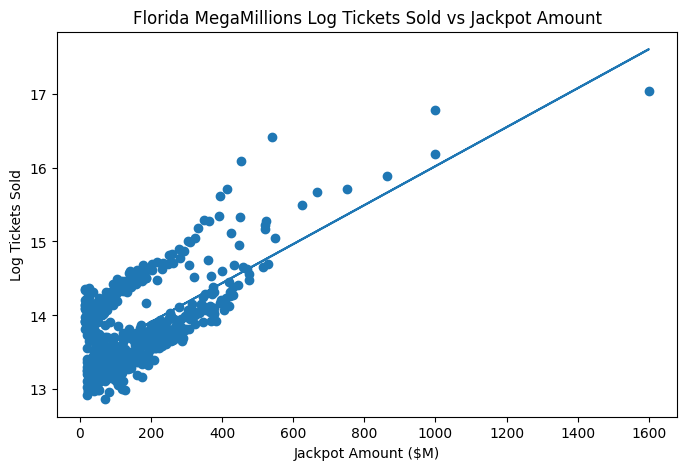

In [70]:
# log scatter plot - show how log tickets sold changes as the amount of jackpot changes

plt.figure(figsize=(8,5))
plt.scatter(df["jackpot_amount($)"],df["log_tickets_sold"])

m,b = np.polyfit(df["jackpot_amount($)"], df["log_tickets_sold"],1)
plt.plot(df["jackpot_amount($)"], m*df["jackpot_amount($)"]+b)

plt.xlabel("Jackpot Amount ($M)")
plt.ylabel("Log Tickets Sold")
plt.title("Florida MegaMillions Log Tickets Sold vs Jackpot Amount")
plt.show()

The scatter plot shows a positive association between Florida MegaMillions jackpot amount and log ticket sales. As the jackpot increases, log ticket sales generally increase as well, indicating that larger jackpots are associated with higher ticket sales. The relationship appears more linear on the log scale, although some variability remains, especially at higher jackpot amounts.

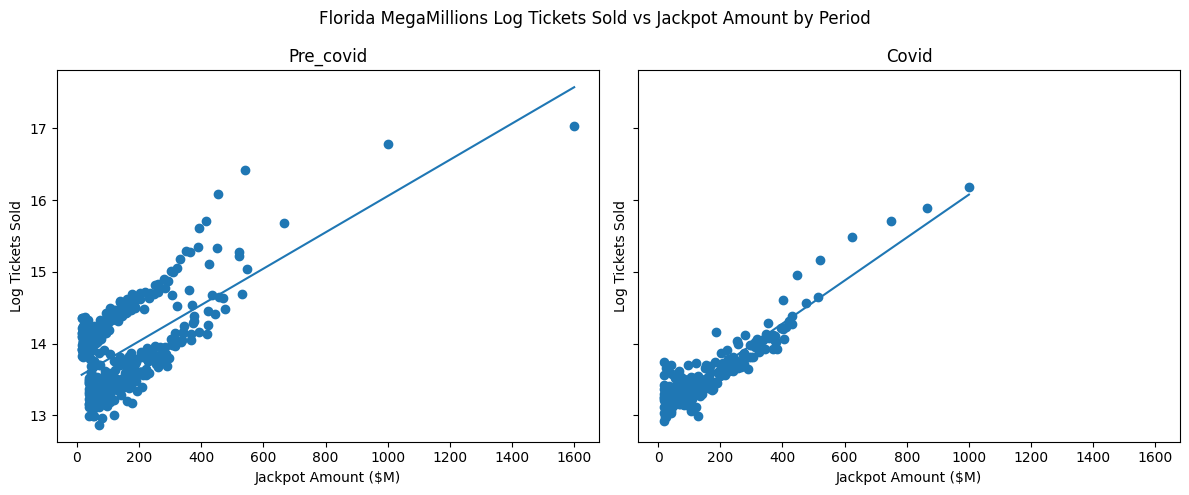

In [71]:
# compare scatter plots of log tickets sold between periods

# set the same scale for both scatter plots and regression lines 
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Pre-Covid
x_pre = df.loc[df["covid"] == 0, "jackpot_amount($)"] # locate the covid==0 rows, and take the corresponding jackpot 
y_pre = df.loc[df["covid"] == 0, "log_tickets_sold"] # locate the covid==0 rows, and take the corresponding tickets sold 

axes[0].scatter(x_pre, y_pre)
slope_pre, intercept_pre = np.polyfit(x_pre, y_pre, 1)
x_pre_sorted = np.sort(x_pre)
axes[0].plot(x_pre_sorted, slope_pre * x_pre_sorted + intercept_pre)
axes[0].set_title("Pre_covid")
axes[0].set_xlabel("Jackpot Amount ($M)")
axes[0].set_ylabel("Log Tickets Sold")

# Covid
x_covid = df.loc[df["covid"] == 1, "jackpot_amount($)"]
y_covid = df.loc[df["covid"] == 1, "log_tickets_sold"]

axes[1].scatter(x_covid, y_covid)
slope_covid, intercept_covid = np.polyfit(x_covid, y_covid, 1)
x_covid_sorted = np.sort(x_covid)
axes[1].plot(x_covid_sorted, slope_covid * x_covid_sorted + intercept_covid)
axes[1].set_title("Covid")
axes[1].set_xlabel("Jackpot Amount ($M)")
axes[1].set_ylabel("Log Tickets Sold")

plt.suptitle("Florida MegaMillions Log Tickets Sold vs Jackpot Amount by Period")
plt.tight_layout() # adjust spacing automatically (e.g., prevents title overlapping..)
plt.show()

In both the Pre_Covid and Covid periods, Florida MegaMillions shows a positive association between jackpot amount and log ticket sales. The relationship appears somewhat stronger in the Covid period, where the fitted line is steeper and the points follow the trend more closely. Overall, larger jackpots are associated with higher log ticket sales in both periods.

<br>

# Preparation for Building Regression Models
### Check correlation and create new variables

In [72]:
# create "lag_jackpot($)" - each row uses the previous drawing's jackpot amount
# sort by draw_date before creating lag variables
df = df.sort_values("draw_date").reset_index(drop=True)

df["lag_jackpot($)"] = df["jackpot_amount($)"].shift(1)

In [73]:
# create interaction terms: "lag_jackpot_covid", "unemployment_rate_covid", and "lag_jackpot_unemployment_rate"
df["lag_jackpot($)_covid"] = df["lag_jackpot($)"]*df["covid"]
df["unemployment_rate_covid"] = df["unemployment_rate"]*df["covid"]
df["lag_jackpot($)_unemployment_rate"] = df["lag_jackpot($)"]*df["unemployment_rate"]

In [74]:
# create year dummies 
df["year"] = np.nan

df.loc[df["year2016"] == 1, "year"] = 2016
df.loc[df["year2017"] == 1, "year"] = 2017
df.loc[df["year2018"] == 1, "year"] = 2018
df.loc[df["year2019"] == 1, "year"] = 2019
df.loc[df["year2020"] == 1, "year"] = 2020
df.loc[df["year2021"] == 1, "year"] = 2021
df.loc[df["year2022"] == 1, "year"] = 2022

<br>

# Build 3 Regression Models

In [75]:
# check variables again 
print(df.columns)

Index(['draw_date', 'winners', 'jackpot_amount($)', 'covid', 'covid_cases',
       'tuesday', 'unemployment_rate_adjusted', 'unemployment_rate', 'jan',
       'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sept', 'oct', 'nov',
       'dec', 'year2016', 'year2017', 'year2018', 'year2019', 'year2020',
       'year2021', 'year2022', 'tickets_sold', 'covid_period', 'covid_label',
       'log_tickets_sold', 'lag_jackpot($)', 'lag_jackpot($)_covid',
       'unemployment_rate_covid', 'lag_jackpot($)_unemployment_rate', 'year'],
      dtype='object')


In [76]:
# Model 1
# since lag jackpot was created using "shift1", the first row may be empty and it needs to be dropped 

model_vars_1 = ["log_tickets_sold", "covid", "lag_jackpot($)", "unemployment_rate", "tuesday"]
df1 = df[model_vars_1].dropna()

# choose predictors and target variable
X1 = df1[["covid","lag_jackpot($)","unemployment_rate","tuesday"]]
X1 = sm.add_constant(X1)
y = df1["log_tickets_sold"]

# fit the model
model1 = sm.OLS(y,X1).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:       log_tickets_sold   R-squared:                       0.372
Model:                            OLS   Adj. R-squared:                  0.368
Method:                 Least Squares   F-statistic:                     89.45
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           1.09e-59
Time:                        17:11:08   Log-Likelihood:                -392.41
No. Observations:                 609   AIC:                             794.8
Df Residuals:                     604   BIC:                             816.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                13.4735      0.05

In [77]:
# Model 2
# since lag jackpot was created using "shift1", the first row may be empty and it needs to be dropped 
model_vars_2 = ["log_tickets_sold", "covid", "lag_jackpot($)", "lag_jackpot($)_covid","unemployment_rate", "unemployment_rate_covid","tuesday"]
df2 = df[model_vars_2].dropna()

# choose predictors and target variable
X2 = df2[["covid","lag_jackpot($)","lag_jackpot($)_covid","unemployment_rate","unemployment_rate_covid","tuesday"]]
X2 = sm.add_constant(X2)
y = df2["log_tickets_sold"]

# fit the model
model2 = sm.OLS(y,X2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:       log_tickets_sold   R-squared:                       0.587
Model:                            OLS   Adj. R-squared:                  0.583
Method:                 Least Squares   F-statistic:                     142.6
Date:                Wed, 01 Apr 2026   Prob (F-statistic):          3.85e-112
Time:                        17:11:13   Log-Likelihood:                -264.77
No. Observations:                 609   AIC:                             543.5
Df Residuals:                     602   BIC:                             574.4
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [78]:
# Model 3
# since lag jackpot was created using "shift1", the first row may be empty and it needs to be dropped 

model_vars_3 = ["log_tickets_sold", "covid", "lag_jackpot($)", "lag_jackpot($)_covid","unemployment_rate", "unemployment_rate_covid","lag_jackpot($)_unemployment_rate","tuesday"]
df3 = df[model_vars_3].dropna()

# choose predictors and target variable
X3 = df3[["covid","lag_jackpot($)","lag_jackpot($)_covid","unemployment_rate","unemployment_rate_covid","lag_jackpot($)_unemployment_rate","tuesday"]]
X3 = sm.add_constant(X3)
y = df3["log_tickets_sold"]

# fit the model
model3 = sm.OLS(y,X3).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:       log_tickets_sold   R-squared:                       0.588
Model:                            OLS   Adj. R-squared:                  0.584
Method:                 Least Squares   F-statistic:                     122.8
Date:                Wed, 01 Apr 2026   Prob (F-statistic):          1.70e-111
Time:                        17:11:18   Log-Likelihood:                -263.71
No. Observations:                 609   AIC:                             543.4
Df Residuals:                     601   BIC:                             578.7
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

<br>

# Compare the models 
### AIC, BIC, Adjusted-R^2

In [79]:
model_comparison_table = pd.DataFrame({
    "Model": ["Model 1", "Model 2", "Model 3"],
    "n_obs": [model1.nobs, model2.nobs, model3.nobs],
    "R_squared": [model1.rsquared, model2.rsquared, model3.rsquared],
    "Adj_R_squared": [model1.rsquared_adj, model2.rsquared_adj, model3.rsquared_adj],
    "AIC": [model1.aic, model2.aic, model3.aic],
    "BIC": [model1.bic, model2.bic, model3.bic]
})

model_comparison_table

,Model,n_obs,R_squared,Adj_R_squared,AIC,BIC
0,Model 1,609.0,0.372010,0.367851,794.821440,816.880532
1,Model 2,609.0,0.587048,0.582932,543.532846,574.415574
2,Model 3,609.0,0.588479,0.583686,543.419591,578.714137


On the log ticket-sales scale, Model 3 was selected as the final model for Florida MegaMillions. It has the highest adjusted R-squared (0.5837) and the lowest AIC (543.42), indicating the best overall fit among the three candidate models. Although Model 2 has the lowest BIC (574.42) and is therefore slightly more parsimonious, Model 3 provides the strongest explanatory performance for Florida MegaMillions log ticket sales.

<br>

# Post Model Inference

In [80]:
def linear_combination_test(results, weights_dict, label="Quantity"):
    parameter_names = results.params.index
    weight_vector = pd.Series(0.0, index=parameter_names)

    for name, weight in weights_dict.items():
        weight_vector[name] = weight

    test_result = results.t_test(weight_vector.values)

    estimate = test_result.effect.item()
    standard_error = test_result.sd.item()
    t_value = test_result.tvalue.item()
    p_value = test_result.pvalue.item()
    ci_lower, ci_upper = test_result.conf_int()[0]

    output = pd.DataFrame({
        "Quantity": [label],
        "Estimate": [estimate],
        "Std_Error": [standard_error],
        "t_value": [t_value],
        "p_value": [p_value],
        "CI_Lower_95": [ci_lower],
        "CI_Upper_95": [ci_upper]
    })

    return output


# sample means used in Model 3 interpretation
mean_lag_jackpot_3 = df3["lag_jackpot($)"].mean()
mean_unempr_3 = df3["unemployment_rate"].mean()
mean_tuesday_3 = df3["tuesday"].mean()

# interaction evaluated at the sample means
mean_interaction_3 = mean_lag_jackpot_3 * mean_unempr_3


# 1) predicted mean log ticket sales before Covid
predicted_mean_before_weights = {
    "const": 1,
    "lag_jackpot($)": mean_lag_jackpot_3,
    "unemployment_rate": mean_unempr_3,
    "lag_jackpot($)_unemployment_rate": mean_interaction_3,
    "tuesday": mean_tuesday_3
}

predicted_mean_before_result = linear_combination_test(
    model3,
    predicted_mean_before_weights,
    label="Predicted Mean Log Ticket Sales Before Covid"
)


# 2) predicted mean log ticket sales during Covid
predicted_mean_during_weights = {
    "const": 1,
    "covid": 1,
    "lag_jackpot($)": mean_lag_jackpot_3,
    "lag_jackpot($)_covid": mean_lag_jackpot_3,
    "unemployment_rate": mean_unempr_3,
    "unemployment_rate_covid": mean_unempr_3,
    "lag_jackpot($)_unemployment_rate": mean_interaction_3,
    "tuesday": mean_tuesday_3
}

predicted_mean_during_result = linear_combination_test(
    model3,
    predicted_mean_during_weights,
    label="Predicted Mean Log Ticket Sales During Covid"
)


# 3) difference in predicted mean log ticket sales (during - before)
difference_in_predicted_mean_weights = {
    "covid": 1,
    "lag_jackpot($)_covid": mean_lag_jackpot_3,
    "unemployment_rate_covid": mean_unempr_3
}

difference_in_predicted_mean_result = linear_combination_test(
    model3,
    difference_in_predicted_mean_weights,
    label="Difference in Predicted Mean Log Ticket Sales (during - before)"
)


# 4) marginal effect of lagged jackpot before Covid
marginal_effect_lagjackpot_before_weights = {
    "lag_jackpot($)": 1,
    "lag_jackpot($)_unemployment_rate": mean_unempr_3
}

marginal_effect_lagjackpot_before_result = linear_combination_test(
    model3,
    marginal_effect_lagjackpot_before_weights,
    label="Marginal Effect of Lagged Jackpot Before Covid"
)


# 5) marginal effect of lagged jackpot during Covid
marginal_effect_lagjackpot_during_weights = {
    "lag_jackpot($)": 1,
    "lag_jackpot($)_covid": 1,
    "lag_jackpot($)_unemployment_rate": mean_unempr_3
}

marginal_effect_lagjackpot_during_result = linear_combination_test(
    model3,
    marginal_effect_lagjackpot_during_weights,
    label="Marginal Effect of Lagged Jackpot During Covid"
)


# 6) difference in marginal effect of lagged jackpot
difference_in_marginal_effect_lagjackpot_weights = {
    "lag_jackpot($)_covid": 1
}

difference_in_marginal_effect_lagjackpot_result = linear_combination_test(
    model3,
    difference_in_marginal_effect_lagjackpot_weights,
    label="Difference in Marginal Effect of Lagged Jackpot"
)


# 7) marginal effect of unemployment rate before Covid
marginal_effect_unempr_before_weights = {
    "unemployment_rate": 1,
    "lag_jackpot($)_unemployment_rate": mean_lag_jackpot_3
}

marginal_effect_unempr_before_result = linear_combination_test(
    model3,
    marginal_effect_unempr_before_weights,
    label="Marginal Effect of Unemployment Rate Before Covid"
)


# 8) marginal effect of unemployment rate during Covid
marginal_effect_unempr_during_weights = {
    "unemployment_rate": 1,
    "unemployment_rate_covid": 1,
    "lag_jackpot($)_unemployment_rate": mean_lag_jackpot_3
}

marginal_effect_unempr_during_result = linear_combination_test(
    model3,
    marginal_effect_unempr_during_weights,
    label="Marginal Effect of Unemployment Rate During Covid"
)


# 9) difference in marginal effect of unemployment rate
difference_in_marginal_effect_unempr_weights = {
    "unemployment_rate_covid": 1
}

difference_in_marginal_effect_unempr_result = linear_combination_test(
    model3,
    difference_in_marginal_effect_unempr_weights,
    label="Difference in Marginal Effect of Unemployment Rate"
)


# combine all post-estimation results
model3_post_estimation_table = pd.concat([
    predicted_mean_before_result,
    predicted_mean_during_result,
    difference_in_predicted_mean_result,
    marginal_effect_lagjackpot_before_result,
    marginal_effect_lagjackpot_during_result,
    difference_in_marginal_effect_lagjackpot_result,
    marginal_effect_unempr_before_result,
    marginal_effect_unempr_during_result,
    difference_in_marginal_effect_unempr_result
], ignore_index=True)

model3_post_estimation_table

,Quantity,Estimate,Std_Error,t_value,p_value,CI_Lower_95,CI_Upper_95
0,Predicted Mean Log Ticket Sales Before Covid,14.327234,0.030234,473.872237,0.000000e+00,14.267856,14.386612
1,Predicted Mean Log Ticket Sales During Covid,13.570121,0.029190,464.888068,0.000000e+00,13.512794,13.627448
2,Difference in Predicted Mean Log Ticket Sales ...,-0.757113,0.041972,-18.038596,1.854765e-58,-0.839542,-0.674684
3,Marginal Effect of Lagged Jackpot Before Covid,0.002272,0.000147,15.455664,1.283599e-45,0.001984,0.002561
4,Marginal Effect of Lagged Jackpot During Covid,0.002450,0.000193,12.700958,6.567429e-33,0.002071,0.002829
5,Difference in Marginal Effect of Lagged Jackpot,0.000178,0.000267,0.666391,5.054168e-01,-0.000346,0.000702
6,Marginal Effect of Unemployment Rate Before Covid,0.482712,0.027352,17.648065,1.789376e-56,0.428995,0.536430
7,Marginal Effect of Unemployment Rate During Covid,-0.014883,0.008088,-1.840117,6.624400e-02,-0.030766,0.001001
8,Difference in Marginal Effect of Unemployment ...,-0.497595,0.028535,-17.438344,2.055002e-55,-0.553635,-0.441555


Conclusion: Holding other variables at their sample means, Florida MegaMillions predicted log ticket sales declined from 14.327 before Covid to 13.570 during Covid, which corresponds to a drop from about 1.67 million tickets to about 782 thousand tickets. The lagged jackpot effect remained positive in both periods and did not differ significantly across periods. The unemployment-rate effect was strongly positive before Covid but became small and negative during Covid.